# STDA2102: Soft Computing (EL1) - Assignment 2
## Module 3: Genetic Algorithms & Evolutionary Computing (Complete 10 Practical Exercises)

**Course Code:** STDA2102  
**Student Name:** Manish Kumar  
**Practical Evaluation:** Implementation (15), Understanding (10), Code Quality (10), Analysis (10), Record (5) -> Total 50 Pts

---

In [1]:
import os
os.environ['KERAS_BACKEND'] = 'torch'
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
print('Module environment configured successfully.')

Module environment configured successfully.


## Practical 1: Practical 3.1: Population Representation and Encoding Methods

```
Practical 3.1: Population Representation and Encoding Methods
Course: Soft Computing (EL1) - STDA2102 | Module 3: Genetic Algorithms

Aim:
To create and represent a population of individuals using different encoding methods in Python.

Theory:
In Evolutionary Computing, candidate solutions are encoded into chromosomes.
The primary representation schemes include:
1. Binary Encoding: Chromosomes are strings of bits ∈ {0, 1}. Standard for discrete problems.
2. Real-Valued (Continuous) Encoding: Chromosomes are vectors of floating-point numbers ∈ [a, b].
   Naturally represents continuous optimization variables without quantization error.
3. Permutation Encoding: Chromosomes are ordered permutations of integers [0, 1, ..., n-1].
   Mandatory for ordering/routing problems like the Traveling Salesperson Problem (TSP).
4. Gray Code Encoding: Reflected binary code where consecutive integers differ by exactly one bit,
   eliminating the "Hamming Cliff" phenomenon in standard binary encoding.
```

PRACTICAL 3.1: Genetic Algorithm Population Encodings

1. Binary Encoded Population (Length 8 bits):
   Ind 1: [0, 1, 0, 0, 0, 1, 0, 0] -> Decimal Value = 68
   Ind 2: [0, 1, 0, 0, 0, 0, 1, 0] -> Decimal Value = 66
   Ind 3: [1, 1, 1, 0, 1, 0, 1, 1] -> Decimal Value = 235
   Ind 4: [1, 1, 1, 1, 1, 1, 0, 0] -> Decimal Value = 252
   Ind 5: [1, 1, 1, 0, 1, 0, 0, 0] -> Decimal Value = 232
   Ind 6: [0, 0, 1, 1, 1, 1, 1, 0] -> Decimal Value = 62

2. Real-Valued Encoded Population (3D Continuous Variables):
   Ind 1: [-0.879,  5.704, -6.007]
   Ind 2: [ 0.285,  1.848, -9.071]
   Ind 3: [ 2.151, -6.590, -8.699]
   Ind 4: [ 8.978,  9.313,  6.168]
   Ind 5: [-3.908, -8.047,  3.685]
   Ind 6: [-1.197, -7.559, -0.096]

3. Permutation Encoded Population (5-City Tour for TSP):
   Ind 1: Tour = [4, 3, 0, 1, 2]
   Ind 2: Tour = [0, 2, 4, 3, 1]
   Ind 3: Tour = [2, 0, 4, 3, 1]
   Ind 4: Tour = [0, 2, 3, 4, 1]
   Ind 5: Tour = [0, 4, 2, 1, 3]
   Ind 6: Tour = [4, 2, 1, 0, 3]

4. Hamming Distance Compa

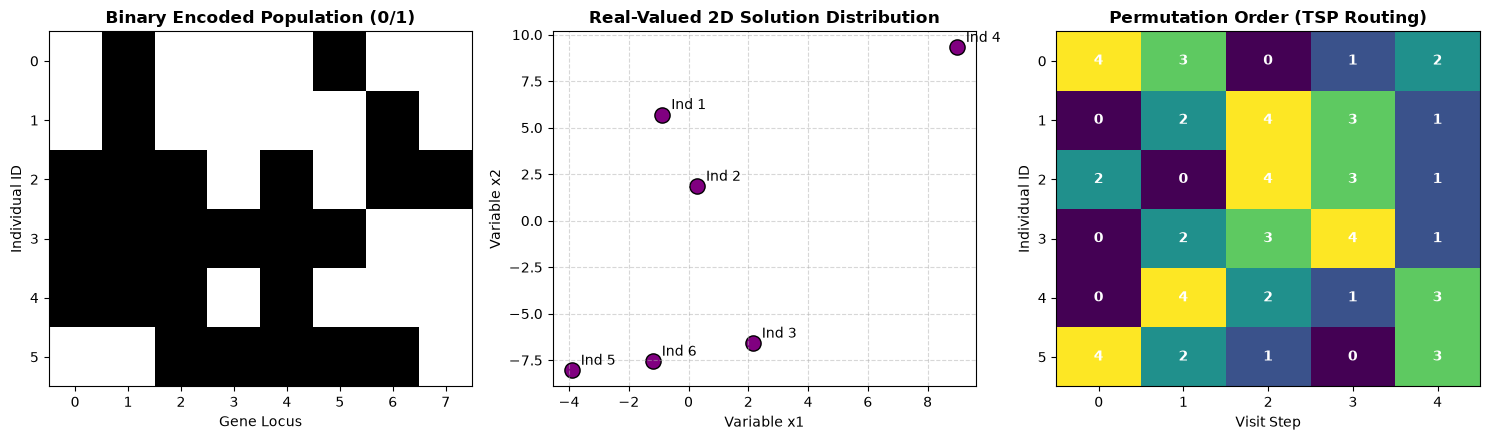


[✓] Plot saved successfully to: /Users/manish/Developer/Assignments/Assignment_2_Practicals/Module_3_Genetic_Algorithms/../output_plots/mod3_ex01_population_encoding.png
[✓] Practical 3.1 completed successfully.



In [2]:
import os
import numpy as np
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt

OUTPUT_DIR = os.path.join(os.getcwd(), "..", "output_plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

def binary_to_gray(n):
    """Converts standard binary integer to Gray code integer."""
    return n ^ (n >> 1)

def int_to_bitstring(val, bits=6):
    return [int(b) for b in format(val, f'0{bits}b')]

def generate_binary_population(pop_size, chrom_length):
    return np.random.randint(0, 2, size=(pop_size, chrom_length))

def generate_real_population(pop_size, dimensions, lower_bound=-5.0, upper_bound=5.0):
    return np.random.uniform(lower_bound, upper_bound, size=(pop_size, dimensions))

def generate_permutation_population(pop_size, num_cities):
    return np.array([np.random.permutation(num_cities) for _ in range(pop_size)])

def generate_gray_population(pop_size, bits=6):
    integers = np.random.randint(0, 2**bits, size=pop_size)
    gray_pop = [int_to_bitstring(binary_to_gray(val), bits) for val in integers]
    return np.array(gray_pop), integers

def run_practical_3_1():
    print("=" * 60)
    print("PRACTICAL 3.1: Genetic Algorithm Population Encodings")
    print("=" * 60)

    pop_size = 6
    np.random.seed(42)

    # 1. Binary Encoding
    bin_pop = generate_binary_population(pop_size, chrom_length=8)
    print("\n1. Binary Encoded Population (Length 8 bits):")
    for i, ind in enumerate(bin_pop):
        print(f"   Ind {i+1}: {ind.tolist()} -> Decimal Value = {int(''.join(map(str, ind)), 2)}")

    # 2. Real-Valued Encoding
    real_pop = generate_real_population(pop_size, dimensions=3, lower_bound=-10.0, upper_bound=10.0)
    print("\n2. Real-Valued Encoded Population (3D Continuous Variables):")
    for i, ind in enumerate(real_pop):
        print(f"   Ind {i+1}: [{ind[0]:6.3f}, {ind[1]:6.3f}, {ind[2]:6.3f}]")

    # 3. Permutation Encoding
    perm_pop = generate_permutation_population(pop_size, num_cities=5)
    print("\n3. Permutation Encoded Population (5-City Tour for TSP):")
    for i, ind in enumerate(perm_pop):
        print(f"   Ind {i+1}: Tour = {ind.tolist()}")

    # 4. Gray Code vs Binary (Hamming Cliff demonstration)
    print("\n4. Hamming Distance Comparison: Standard Binary vs. Gray Code (Transition 3 -> 4):")
    bin_3 = format(3, '04b')
    bin_4 = format(4, '04b')
    gray_3 = format(binary_to_gray(3), '04b')
    gray_4 = format(binary_to_gray(4), '04b')
    bin_hd = sum(c1 != c2 for c1, c2 in zip(bin_3, bin_4))
    gray_hd = sum(c1 != c2 for c1, c2 in zip(gray_3, gray_4))
    print(f"   Decimal 3 ({bin_3}) -> 4 ({bin_4}) in Binary: Hamming Distance = {bin_hd} (Hamming Cliff!)")
    print(f"   Decimal 3 ({gray_3}) -> 4 ({gray_4}) in Gray Code: Hamming Distance = {gray_hd} (Single-bit transition)")

    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    # Binary Population Grid
    axes[0].imshow(bin_pop, cmap='binary', aspect='auto')
    axes[0].set_title("Binary Encoded Population (0/1)", fontweight='bold')
    axes[0].set_xlabel("Gene Locus")
    axes[0].set_ylabel("Individual ID")

    # Real-Valued Scatter
    axes[1].scatter(real_pop[:, 0], real_pop[:, 1], c='purple', s=120, edgecolors='black')
    for i in range(pop_size):
        axes[1].annotate(f"Ind {i+1}", (real_pop[i, 0]+0.3, real_pop[i, 1]+0.3))
    axes[1].set_title("Real-Valued 2D Solution Distribution", fontweight='bold')
    axes[1].set_xlabel("Variable x1")
    axes[1].set_ylabel("Variable x2")
    axes[1].grid(True, linestyle='--', alpha=0.5)

    # Permutation Matrix Visualization
    axes[2].imshow(perm_pop, cmap='viridis', aspect='auto')
    for i in range(pop_size):
        for j in range(5):
            axes[2].text(j, i, str(perm_pop[i, j]), ha='center', va='center', color='white', fontweight='bold')
    axes[2].set_title("Permutation Order (TSP Routing)", fontweight='bold')
    axes[2].set_xlabel("Visit Step")
    axes[2].set_ylabel("Individual ID")

    plt.tight_layout()
    plot_path = os.path.join(OUTPUT_DIR, "mod3_ex01_population_encoding.png")
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f"\n[✓] Plot saved successfully to: {plot_path}")
    print("[✓] Practical 3.1 completed successfully.\n")

if True:
    run_practical_3_1()

## Practical 2: Practical 3.2: Fitness Function Formulation and Evaluation

```
Practical 3.2: Fitness Function Formulation and Evaluation
Course: Soft Computing (EL1) - STDA2102 | Module 3: Genetic Algorithms

Aim:
To define and calculate a simple fitness function for evaluating individuals in a Genetic Algorithm using Python.

Theory:
The Fitness Function transforms an individual's chromosome into a non-negative scalar score
representing reproductive capability.
1. Minimization-to-Maximization Mapping:
   When minimizing an objective function g(x) >= 0:
       Fitness f(x) = 1.0 / (1.0 + g(x))   or   f(x) = C_max - g(x)
2. Benchmark Optimization Landscapes:
   - Sphere Function (Unimodal): f_sphere(x) = ∑ x_i^2, Global minimum at x* = 0
   - Rastrigin Function (Highly Multimodal with complex local traps):
       f_rastrigin(x) = 10*d + ∑ [x_i^2 - 10*cos(2π*x_i)]
```

PRACTICAL 3.2: Fitness Function Definition & Evaluation
 Individual  |   Coordinates (x1, x2)   |  Cost g(x)   |  Fitness f(x) 
----------------------------------------------------------------------
Ind  1       |      ( 0.00,  0.00)      |       0.0000 |       1.000000
Ind  2       |      ( 1.00,  1.00)      |       2.0000 |       0.333333
Ind  3       |      ( 2.50, -3.20)      |      43.3998 |       0.022523
Ind  4       |      (-4.50,  4.20)      |      64.7998 |       0.015198


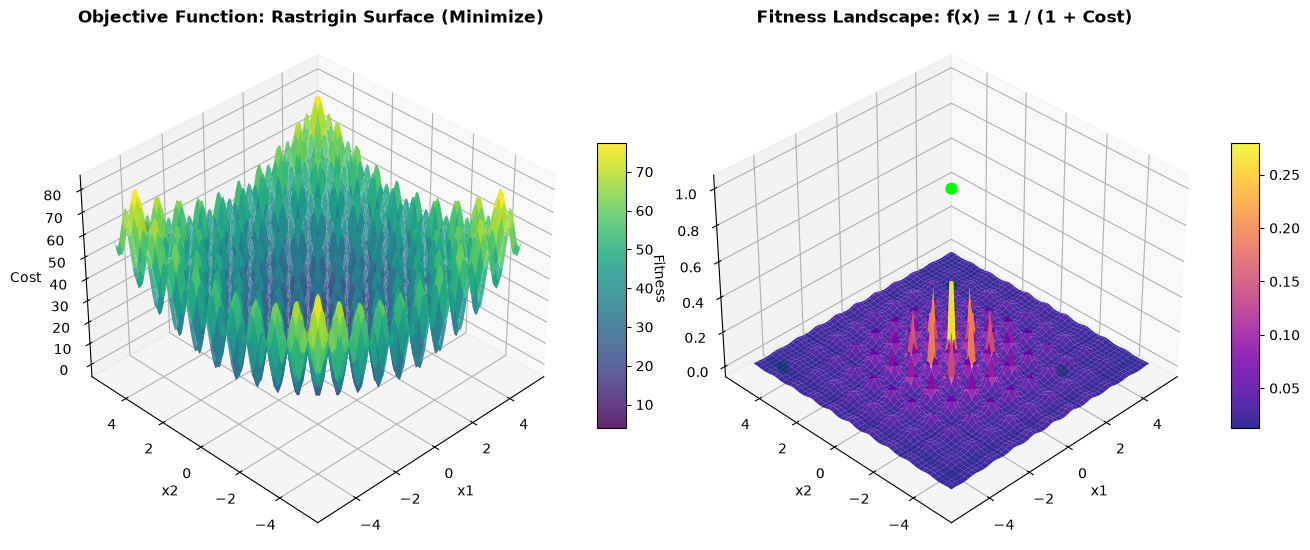


[✓] Plot saved successfully to: /Users/manish/Developer/Assignments/Assignment_2_Practicals/Module_3_Genetic_Algorithms/../output_plots/mod3_ex02_fitness_functions.png
[✓] Practical 3.2 completed successfully.



In [3]:
import os
import numpy as np
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt

OUTPUT_DIR = os.path.join(os.getcwd(), "..", "output_plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

def sphere_objective(X):
    """X: shape (N, d)"""
    return np.sum(X ** 2, axis=-1)

def rastrigin_objective(X):
    """X: shape (N, d)"""
    d = X.shape[-1]
    return 10 * d + np.sum(X ** 2 - 10 * np.cos(2 * np.pi * X), axis=-1)

def fitness_from_cost(cost):
    """Maps cost (to minimize) into positive fitness (to maximize)."""
    return 1.0 / (1.0 + cost)

def run_practical_3_2():
    print("=" * 60)
    print("PRACTICAL 3.2: Fitness Function Definition & Evaluation")
    print("=" * 60)

    # Test candidate individuals on 2D Rastrigin function
    candidates = np.array([
        [0.0, 0.0],       # Global Optimum
        [1.0, 1.0],       # Near local minimum
        [2.5, -3.2],      # Suboptimal point
        [-4.5, 4.2]       # Poor individual near domain boundary
    ])

    costs = rastrigin_objective(candidates)
    fitnesses = fitness_from_cost(costs)

    print(f"{'Individual':^12} | {'Coordinates (x1, x2)':^24} | {'Cost g(x)':^12} | {'Fitness f(x)':^14}")
    print("-" * 70)
    for i in range(len(candidates)):
        coords = f"({candidates[i, 0]:5.2f}, {candidates[i, 1]:5.2f})"
        print(f"Ind {i+1:2d}       | {coords:^24} | {costs[i]:12.4f} | {fitnesses[i]:14.6f}")

    # Visualization: 3D Rastrigin Fitness Landscape
    x1 = np.linspace(-5.12, 5.12, 100)
    x2 = np.linspace(-5.12, 5.12, 100)
    X1, X2 = np.meshgrid(x1, x2)
    grid = np.stack([X1, X2], axis=-1)
    Z_cost = rastrigin_objective(grid)
    Z_fit = fitness_from_cost(Z_cost)

    fig = plt.figure(figsize=(13, 6))

    # Cost Landscape (3D Surface)
    ax1 = fig.add_subplot(121, projection='3d')
    surf1 = ax1.plot_surface(X1, X2, Z_cost, cmap='viridis', edgecolor='none', alpha=0.85)
    ax1.scatter(candidates[:, 0], candidates[:, 1], costs, color='red', s=60, label='Candidate Individuals')
    ax1.set_title("Objective Function: Rastrigin Surface (Minimize)", fontweight='bold')
    ax1.set_xlabel("x1")
    ax1.set_ylabel("x2")
    ax1.set_zlabel("Cost")
    ax1.view_init(elev=35, azim=225)
    fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)

    # Fitness Landscape (Inverted / Scaled to Maximize)
    ax2 = fig.add_subplot(122, projection='3d')
    surf2 = ax2.plot_surface(X1, X2, Z_fit, cmap='plasma', edgecolor='none', alpha=0.85)
    ax2.scatter(candidates[:, 0], candidates[:, 1], fitnesses, color='lime', s=60, label='Candidates')
    ax2.set_title("Fitness Landscape: f(x) = 1 / (1 + Cost)", fontweight='bold')
    ax2.set_xlabel("x1")
    ax2.set_ylabel("x2")
    ax2.set_zlabel("Fitness")
    ax2.view_init(elev=35, azim=225)
    fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10)

    plt.tight_layout()
    plot_path = os.path.join(OUTPUT_DIR, "mod3_ex02_fitness_functions.png")
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f"\n[✓] Plot saved successfully to: {plot_path}")
    print("[✓] Practical 3.2 completed successfully.\n")

if True:
    run_practical_3_2()

## Practical 3: Practical 3.3: Selection Operators in Genetic Algorithms

```
Practical 3.3: Selection Operators in Genetic Algorithms
Course: Soft Computing (EL1) - STDA2102 | Module 3: Genetic Algorithms

Aim:
To implement basic selection methods for selecting suitable individuals from a population using Python.

Theory:
Selection operators model the Darwinian principle of "survival of the fittest".
1. Roulette Wheel Selection (Fitness Proportionate):
   Each individual i is assigned a selection probability:
       P(i) = f_i / ∑_{j=1}^N f_j
   Individuals with higher fitness occupy larger sectors on the wheel.
2. Tournament Selection:
   k individuals are chosen at random from the population; the one with highest fitness wins.
   Tournament size k controls selection pressure (larger k = higher exploitation).
3. Rank Selection:
   Individuals are sorted in ascending order of fitness and assigned ranks 1 to N.
   Selection probability is proportional to rank, eliminating scaling stagnation and premature convergence.
4. Stochastic Universal Sampling (SUS):
   Uses a single spin with N equally spaced pointers, providing zero-bias and minimal spread.
```

PRACTICAL 3.3: Selection Operators Comparison
Initial Population & Fitness Values:
  Ind_1: Fitness =   12.0 ( 3.20%)
  Ind_2: Fitness =   45.0 (12.00%)
  Ind_3: Fitness =    8.0 ( 2.13%)
  Ind_4: Fitness =   95.0 (25.33%)
  Ind_5: Fitness =   22.0 ( 5.87%)
  Ind_6: Fitness =   68.0 (18.13%)
  Ind_7: Fitness =   15.0 ( 4.00%)
  Ind_8: Fitness =  110.0 (29.33%)

Empirical Selection Probability Across 2000 Draws:
Individual |  True Fit %  |  Roulette %  |  Tournament %  |   Rank %   |   SUS %   
---------------------------------------------------------------------------
  Ind_1    |        3.20% |        2.80% |          0.00% |      5.65% |      3.20%
  Ind_2    |       12.00% |       11.85% |          9.65% |     13.20% |     12.00%
  Ind_3    |        2.13% |        2.00% |          0.00% |      3.15% |      2.15%
  Ind_4    |       25.33% |       25.10% |         26.70% |     19.80% |     25.35%
  Ind_5    |        5.87% |        6.00% |          5.65% |     10.15% |      5.85%
  Ind

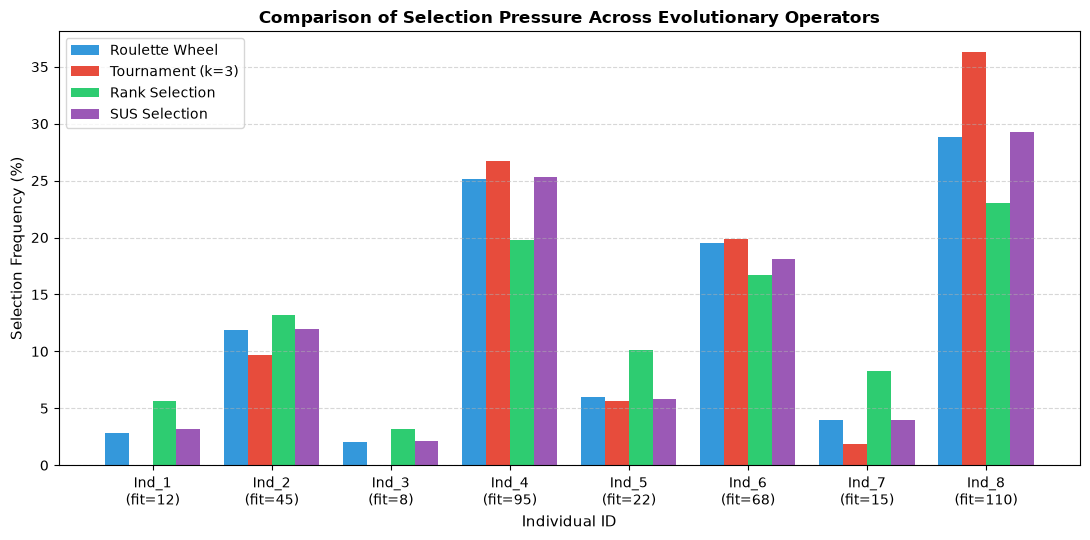


[✓] Plot saved successfully to: /Users/manish/Developer/Assignments/Assignment_2_Practicals/Module_3_Genetic_Algorithms/../output_plots/mod3_ex03_selection_methods.png
[✓] Practical 3.3 completed successfully.



In [4]:
import os
import numpy as np
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt

OUTPUT_DIR = os.path.join(os.getcwd(), "..", "output_plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

def roulette_wheel_selection(population, fitnesses, num_select=10):
    probs = fitnesses / np.sum(fitnesses)
    indices = np.random.choice(len(population), size=num_select, p=probs)
    return population[indices], indices

def tournament_selection(population, fitnesses, num_select=10, k=3):
    selected_indices = []
    for _ in range(num_select):
        contenders = np.random.choice(len(population), size=k, replace=False)
        winner = contenders[np.argmax(fitnesses[contenders])]
        selected_indices.append(winner)
    return population[selected_indices], np.array(selected_indices)

def rank_selection(population, fitnesses, num_select=10):
    sorted_idx = np.argsort(fitnesses) # lowest to highest
    ranks = np.empty_like(sorted_idx)
    ranks[sorted_idx] = np.arange(1, len(fitnesses) + 1)
    probs = ranks / np.sum(ranks)
    indices = np.random.choice(len(population), size=num_select, p=probs)
    return population[indices], indices

def sus_selection(population, fitnesses, num_select=10):
    total_fit = np.sum(fitnesses)
    step = total_fit / num_select
    start = np.random.uniform(0, step)
    pointers = [start + i * step for i in range(num_select)]

    cum_fit = np.cumsum(fitnesses)
    selected_indices = []
    for p in pointers:
        idx = np.searchsorted(cum_fit, p)
        selected_indices.append(min(idx, len(population) - 1))
    return population[selected_indices], np.array(selected_indices)

def run_practical_3_3():
    print("=" * 60)
    print("PRACTICAL 3.3: Selection Operators Comparison")
    print("=" * 60)

    # Population of 8 individuals with varying fitness
    pop_size = 8
    population = np.array([f"Ind_{i+1}" for i in range(pop_size)])
    fitnesses = np.array([12.0, 45.0, 8.0, 95.0, 22.0, 68.0, 15.0, 110.0])

    print("Initial Population & Fitness Values:")
    for ind, fit in zip(population, fitnesses):
        print(f"  {ind}: Fitness = {fit:6.1f} ({fit/np.sum(fitnesses)*100:5.2f}%)")

    # Run 1000 sampling trials to compare theoretical vs empirical selection frequency
    n_trials = 2000
    _, rw_idx = roulette_wheel_selection(population, fitnesses, n_trials)
    _, tour_idx = tournament_selection(population, fitnesses, n_trials, k=3)
    _, rank_idx = rank_selection(population, fitnesses, n_trials)
    _, sus_idx = sus_selection(population, fitnesses, n_trials)

    rw_freq = np.bincount(rw_idx, minlength=pop_size) / n_trials
    tour_freq = np.bincount(tour_idx, minlength=pop_size) / n_trials
    rank_freq = np.bincount(rank_idx, minlength=pop_size) / n_trials
    sus_freq = np.bincount(sus_idx, minlength=pop_size) / n_trials

    print("\nEmpirical Selection Probability Across 2000 Draws:")
    print(f"{'Individual':^10} | {'True Fit %':^12} | {'Roulette %':^12} | {'Tournament %':^14} | {'Rank %':^10} | {'SUS %':^10}")
    print("-" * 75)
    for i in range(pop_size):
        tf = (fitnesses[i] / np.sum(fitnesses)) * 100.0
        print(f"{population[i]:^10} | {tf:11.2f}% | {rw_freq[i]*100:11.2f}% | {tour_freq[i]*100:13.2f}% | {rank_freq[i]*100:9.2f}% | {sus_freq[i]*100:9.2f}%")

    # Visualization
    fig, ax = plt.subplots(figsize=(11, 5.5))
    x_pos = np.arange(pop_size)
    width = 0.2

    ax.bar(x_pos - 1.5*width, rw_freq*100, width, label='Roulette Wheel', color='#3498db')
    ax.bar(x_pos - 0.5*width, tour_freq*100, width, label='Tournament (k=3)', color='#e74c3c')
    ax.bar(x_pos + 0.5*width, rank_freq*100, width, label='Rank Selection', color='#2ecc71')
    ax.bar(x_pos + 1.5*width, sus_freq*100, width, label='SUS Selection', color='#9b59b6')

    ax.set_title("Comparison of Selection Pressure Across Evolutionary Operators", fontsize=12, fontweight='bold')
    ax.set_xlabel("Individual ID", fontsize=11)
    ax.set_ylabel("Selection Frequency (%)", fontsize=11)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f"{ind}\n(fit={fit:.0f})" for ind, fit in zip(population, fitnesses)])
    ax.grid(True, linestyle='--', alpha=0.5, axis='y')
    ax.legend()

    plt.tight_layout()
    plot_path = os.path.join(OUTPUT_DIR, "mod3_ex03_selection_methods.png")
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f"\n[✓] Plot saved successfully to: {plot_path}")
    print("[✓] Practical 3.3 completed successfully.\n")

if True:
    run_practical_3_3()

## Practical 4: Practical 3.4: Crossover (Recombination) Operators

```
Practical 3.4: Crossover (Recombination) Operators
Course: Soft Computing (EL1) - STDA2102 | Module 3: Genetic Algorithms

Aim:
To implement the crossover operation for generating new offspring from selected individuals using Python.

Theory:
Crossover combines the genetic material of two parent chromosomes to produce offspring:
1. Single-Point Crossover: A crossover point k is chosen at random; genes beyond k are exchanged.
2. Two-Point Crossover: Two points k1 < k2 are chosen; genes between k1 and k2 are exchanged,
   reducing positional bias.
3. Uniform Crossover: Each gene is inherited from parent 1 or parent 2 based on a random binary mask.
4. Order Crossover (OX1): Specialized for permutation representations (e.g., TSP).
   Preserves relative order and prevents duplicate allele entries.
5. Arithmetic Crossover: For continuous/real-valued encodings:
       c1 = α * p1 + (1 - α) * p2
       c2 = (1 - α) * p1 + α * p2
```

PRACTICAL 3.4: Crossover (Recombination) Operations
Parent 1: [1, 1, 1, 1, 1, 1, 1, 1]
Parent 2: [0, 0, 0, 0, 0, 0, 0, 0]

1. Single-Point Crossover (Cut at index 4):
   Offspring 1: [1, 1, 1, 1, 0, 0, 0, 0]
   Offspring 2: [0, 0, 0, 0, 1, 1, 1, 1]

2. Two-Point Crossover (Cuts at (2, 6)):
   Offspring 1: [1, 1, 0, 0, 0, 0, 1, 1]
   Offspring 2: [0, 0, 1, 1, 1, 1, 0, 0]

3. Uniform Crossover (Mask: [1, 0, 1, 0, 0, 1, 0, 1]):
   Offspring 1: [0, 1, 0, 1, 1, 0, 1, 0]
   Offspring 2: [1, 0, 1, 0, 0, 1, 0, 1]

4. Order Crossover OX1 (Permutations, cuts (3, 6)):
   Permutation Parent 1: [1, 2, 3, 4, 5, 6, 7, 8]
   Permutation Parent 2: [8, 7, 6, 5, 4, 3, 2, 1]
   Valid Offspring (OX1): [8, 7, 3, 4, 5, 6, 2, 1] (No duplicates, valid tour!)


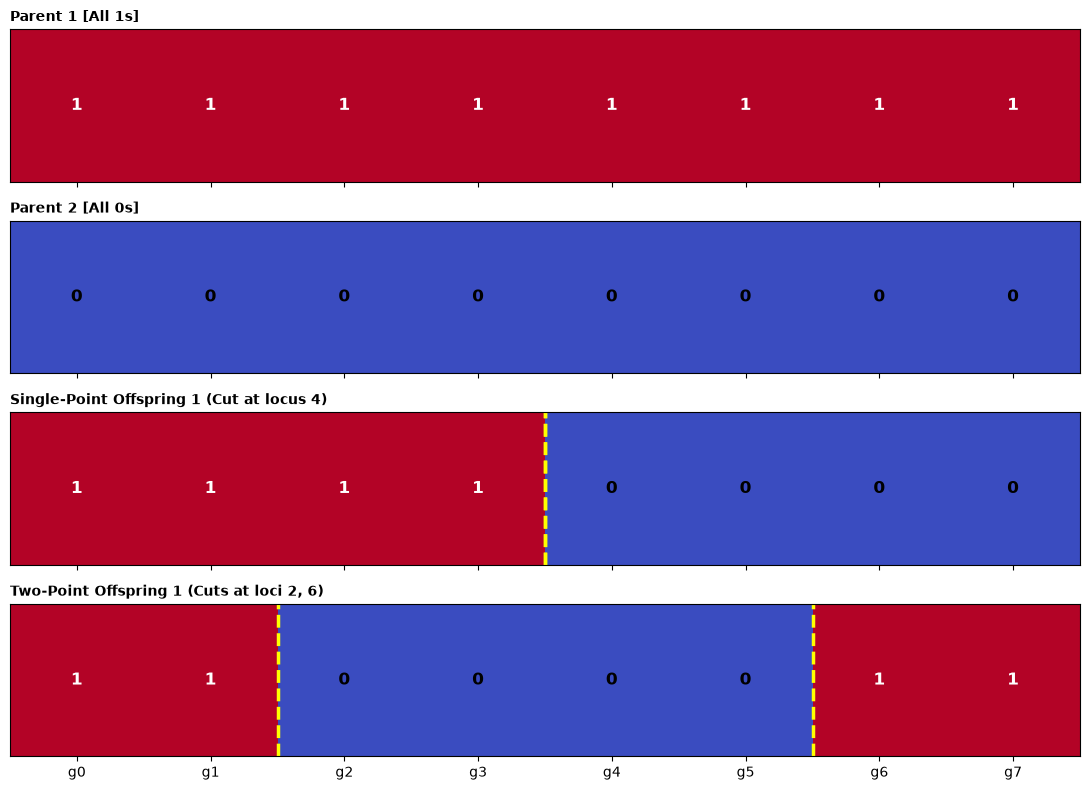


[✓] Plot saved successfully to: /Users/manish/Developer/Assignments/Assignment_2_Practicals/Module_3_Genetic_Algorithms/../output_plots/mod3_ex04_crossover_operators.png
[✓] Practical 3.4 completed successfully.



In [5]:
import os
import numpy as np
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt

OUTPUT_DIR = os.path.join(os.getcwd(), "..", "output_plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

def single_point_crossover(p1, p2, point=None):
    n = len(p1)
    k = np.random.randint(1, n) if point is None else point
    c1 = np.concatenate([p1[:k], p2[k:]])
    c2 = np.concatenate([p2[:k], p1[k:]])
    return c1, c2, k

def two_point_crossover(p1, p2, points=None):
    n = len(p1)
    if points is None:
        pts = np.sort(np.random.choice(range(1, n), size=2, replace=False))
        k1, k2 = pts[0], pts[1]
    else:
        k1, k2 = points
    c1 = np.concatenate([p1[:k1], p2[k1:k2], p1[k2:]])
    c2 = np.concatenate([p2[:k1], p1[k1:k2], p2[k2:]])
    return c1, c2, (k1, k2)

def uniform_crossover(p1, p2, p_swap=0.5, mask=None):
    n = len(p1)
    if mask is None:
        mask = np.random.rand(n) < p_swap
    c1 = np.where(mask, p2, p1)
    c2 = np.where(mask, p1, p2)
    return c1, c2, mask

def order_crossover_ox1(p1, p2, points=None):
    n = len(p1)
    if points is None:
        pts = np.sort(np.random.choice(range(1, n), size=2, replace=False))
        k1, k2 = pts[0], pts[1]
    else:
        k1, k2 = points

    c1 = [None] * n
    c1[k1:k2] = p1[k1:k2]
    p2_remaining = [item for item in p2 if item not in c1[k1:k2]]
    ptr = 0
    for i in range(n):
        if c1[i] is None:
            c1[i] = p2_remaining[ptr]
            ptr += 1
    return np.array(c1), (k1, k2)

def run_practical_3_4():
    print("=" * 60)
    print("PRACTICAL 3.4: Crossover (Recombination) Operations")
    print("=" * 60)

    # Binary Parents
    p1 = np.array([1, 1, 1, 1, 1, 1, 1, 1])
    p2 = np.array([0, 0, 0, 0, 0, 0, 0, 0])

    print("Parent 1:", p1.tolist())
    print("Parent 2:", p2.tolist())

    # 1. Single-Point
    c1_sp, c2_sp, pt_sp = single_point_crossover(p1, p2, point=4)
    print(f"\n1. Single-Point Crossover (Cut at index {pt_sp}):")
    print(f"   Offspring 1: {c1_sp.tolist()}")
    print(f"   Offspring 2: {c2_sp.tolist()}")

    # 2. Two-Point
    c1_tp, c2_tp, pts_tp = two_point_crossover(p1, p2, points=(2, 6))
    print(f"\n2. Two-Point Crossover (Cuts at {pts_tp}):")
    print(f"   Offspring 1: {c1_tp.tolist()}")
    print(f"   Offspring 2: {c2_tp.tolist()}")

    # 3. Uniform Crossover
    mask = np.array([1, 0, 1, 0, 0, 1, 0, 1], dtype=bool)
    c1_un, c2_un, _ = uniform_crossover(p1, p2, mask=mask)
    print(f"\n3. Uniform Crossover (Mask: {mask.astype(int).tolist()}):")
    print(f"   Offspring 1: {c1_un.tolist()}")
    print(f"   Offspring 2: {c2_un.tolist()}")

    # 4. Order Crossover (OX1) for TSP Permutation
    perm_p1 = np.array([1, 2, 3, 4, 5, 6, 7, 8])
    perm_p2 = np.array([8, 7, 6, 5, 4, 3, 2, 1])
    c1_ox, cuts_ox = order_crossover_ox1(perm_p1, perm_p2, points=(3, 6))
    print(f"\n4. Order Crossover OX1 (Permutations, cuts {cuts_ox}):")
    print(f"   Permutation Parent 1: {perm_p1.tolist()}")
    print(f"   Permutation Parent 2: {perm_p2.tolist()}")
    print(f"   Valid Offspring (OX1): {c1_ox.tolist()} (No duplicates, valid tour!)")

    # Visualization
    fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True)

    def plot_chrom(ax, chrom, title, highlight_range=None, highlight_mask=None):
        data = np.array([chrom])
        im = ax.imshow(data, cmap='coolwarm', vmin=0, vmax=1, aspect='auto')
        ax.set_yticks([])
        ax.set_xticks(range(len(chrom)))
        ax.set_xticklabels([f"g{i}" for i in range(len(chrom))])
        ax.set_title(title, fontsize=10, fontweight='bold', loc='left')
        for i, val in enumerate(chrom):
            ax.text(i, 0, str(val), ha='center', va='center', color='white' if val==1 else 'black',
                    fontweight='bold', fontsize=12)
        if highlight_range:
            k1, k2 = highlight_range
            ax.axvline(k1 - 0.5, color='yellow', linestyle='--', linewidth=2.5)
            ax.axvline(k2 - 0.5, color='yellow', linestyle='--', linewidth=2.5)

    plot_chrom(axes[0], p1, "Parent 1 [All 1s]")
    plot_chrom(axes[1], p2, "Parent 2 [All 0s]")
    plot_chrom(axes[2], c1_sp, f"Single-Point Offspring 1 (Cut at locus 4)", highlight_range=(4, 4))
    plot_chrom(axes[3], c1_tp, f"Two-Point Offspring 1 (Cuts at loci 2, 6)", highlight_range=(2, 6))

    plt.tight_layout()
    plot_path = os.path.join(OUTPUT_DIR, "mod3_ex04_crossover_operators.png")
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f"\n[✓] Plot saved successfully to: {plot_path}")
    print("[✓] Practical 3.4 completed successfully.\n")

if True:
    run_practical_3_4()

## Practical 5: Practical 3.5: Mutation Operators in Genetic Algorithms

```
Practical 3.5: Mutation Operators in Genetic Algorithms
Course: Soft Computing (EL1) - STDA2102 | Module 3: Genetic Algorithms

Aim:
To implement the mutation operation for introducing variations in individuals using Python.

Theory:
Mutation is an exploration operator that maintains genetic diversity in the population and prevents
premature convergence to suboptimal local extrema.
Common Mutation Schemes:
1. Bit-Flip Mutation (Binary): Each gene locus is inverted with a small mutation probability P_m (typically 1/L).
2. Swap Mutation (Permutations): Selects two gene loci at random and swaps their positions (preserves permutation validity).
3. Inversion Mutation (Permutations): Reverses the order of genes between two randomly chosen indices.
4. Gaussian Mutation (Continuous / Real-Valued): Adds zero-mean Gaussian perturbation:
       x_mutated = x + N(0, σ^2)
```

PRACTICAL 3.5: Mutation Operators Implementation
1. Bit-Flip Mutation (Binary chromosome):
   Original: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
   Mutated:  [0, 0, 0, 0, 1, 1, 1, 0, 0, 0] (Flipped positions: [4, 5, 6])

2. Swap Mutation (Permutation for TSP):
   Original: [1, 2, 3, 4, 5, 6, 7, 8]
   Mutated:  [3, 2, 1, 4, 5, 6, 7, 8] (Swapped index 0 [val=1] with index 2 [val=3])

3. Inversion Mutation (Permutation):
   Original: [1, 2, 3, 4, 5, 6, 7, 8]
   Mutated:  [1, 2, 6, 5, 4, 3, 7, 8] (Reversed segment [2:5])

4. Gaussian Mutation (Real-Valued Vector):
   Original: [0.0, 0.0, 0.0, 0.0, 0.0]
   Mutated:  [0.2665, -0.9216, 0.171, -0.0416, 1.3612]


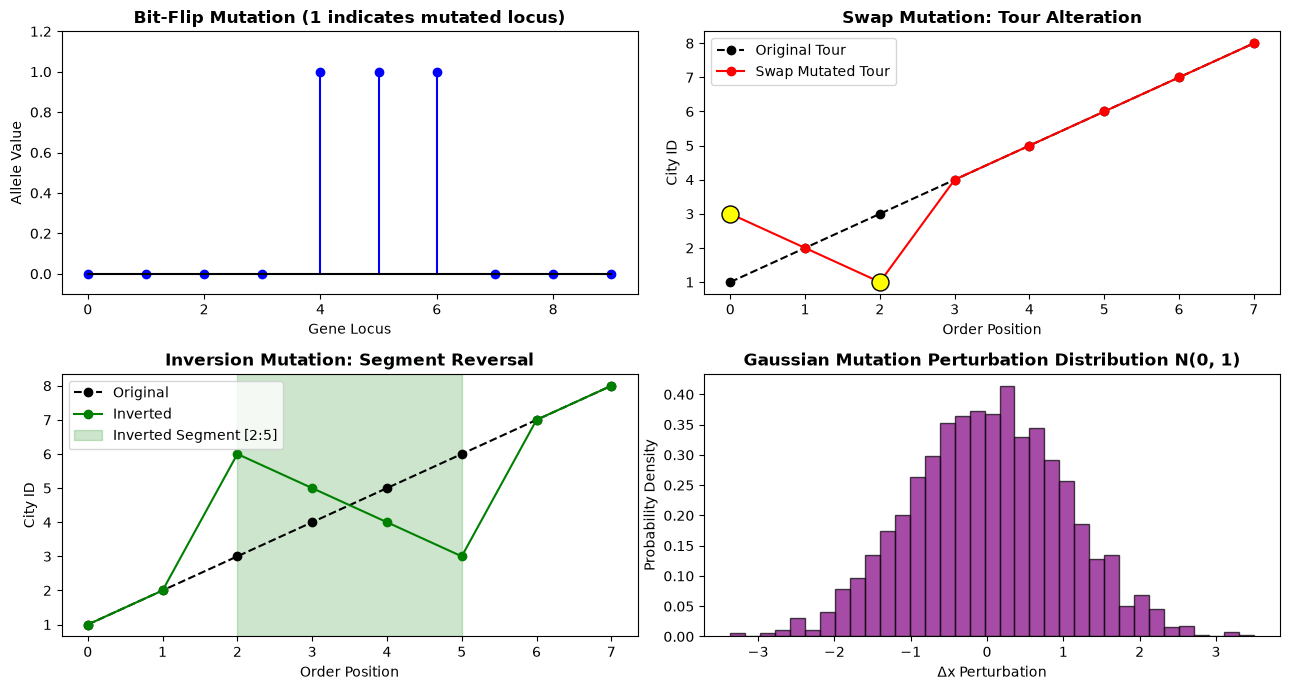


[✓] Plot saved successfully to: /Users/manish/Developer/Assignments/Assignment_2_Practicals/Module_3_Genetic_Algorithms/../output_plots/mod3_ex05_mutation_operators.png
[✓] Practical 3.5 completed successfully.



In [6]:
import os
import numpy as np
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt

OUTPUT_DIR = os.path.join(os.getcwd(), "..", "output_plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

def bit_flip_mutation(chromosome, pm=0.1):
    mutated = chromosome.copy()
    flips = np.random.rand(len(chromosome)) < pm
    mutated[flips] = 1 - mutated[flips]
    return mutated, flips

def swap_mutation(permutation):
    mutated = permutation.copy()
    idx1, idx2 = np.random.choice(len(permutation), size=2, replace=False)
    mutated[idx1], mutated[idx2] = mutated[idx2], mutated[idx1]
    return mutated, (idx1, idx2)

def inversion_mutation(permutation):
    mutated = permutation.copy()
    pts = np.sort(np.random.choice(len(permutation), size=2, replace=False))
    k1, k2 = pts[0], pts[1]
    mutated[k1:k2+1] = mutated[k1:k2+1][::-1]
    return mutated, (k1, k2)

def gaussian_mutation(real_vector, pm=0.3, sigma=0.5, bounds=(-5.0, 5.0)):
    mutated = real_vector.copy()
    mask = np.random.rand(len(real_vector)) < pm
    noise = np.random.normal(0, sigma, size=len(real_vector))
    mutated[mask] += noise[mask]
    mutated = np.clip(mutated, bounds[0], bounds[1])
    return mutated, mask

def run_practical_3_5():
    print("=" * 60)
    print("PRACTICAL 3.5: Mutation Operators Implementation")
    print("=" * 60)

    np.random.seed(42)

    # 1. Bit-Flip Mutation
    orig_bin = np.zeros(10, dtype=int)
    mut_bin, flips = bit_flip_mutation(orig_bin, pm=0.3)
    print("1. Bit-Flip Mutation (Binary chromosome):")
    print(f"   Original: {orig_bin.tolist()}")
    print(f"   Mutated:  {mut_bin.tolist()} (Flipped positions: {np.where(flips)[0].tolist()})")

    # 2. Swap Mutation
    orig_perm = np.array([1, 2, 3, 4, 5, 6, 7, 8])
    mut_swap, (s1, s2) = swap_mutation(orig_perm)
    print("\n2. Swap Mutation (Permutation for TSP):")
    print(f"   Original: {orig_perm.tolist()}")
    print(f"   Mutated:  {mut_swap.tolist()} (Swapped index {s1} [val={orig_perm[s1]}] with index {s2} [val={orig_perm[s2]}])")

    # 3. Inversion Mutation
    mut_inv, (i1, i2) = inversion_mutation(orig_perm)
    print("\n3. Inversion Mutation (Permutation):")
    print(f"   Original: {orig_perm.tolist()}")
    print(f"   Mutated:  {mut_inv.tolist()} (Reversed segment [{i1}:{i2}])")

    # 4. Gaussian Mutation
    orig_real = np.array([0.0, 0.0, 0.0, 0.0, 0.0])
    mut_real, r_mask = gaussian_mutation(orig_real, pm=0.6, sigma=1.2)
    print("\n4. Gaussian Mutation (Real-Valued Vector):")
    print(f"   Original: {orig_real.tolist()}")
    print(f"   Mutated:  {[round(x, 4) for x in mut_real.tolist()]}")

    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(13, 7))

    # Binary mutation visualization
    axes[0, 0].stem(range(len(orig_bin)), mut_bin, linefmt='b-', markerfmt='bo', basefmt='k-')
    axes[0, 0].set_title("Bit-Flip Mutation (1 indicates mutated locus)", fontweight='bold')
    axes[0, 0].set_xlabel("Gene Locus")
    axes[0, 0].set_ylabel("Allele Value")
    axes[0, 0].set_ylim(-0.1, 1.2)

    # Permutation Swap visualization
    axes[0, 1].plot(range(len(orig_perm)), orig_perm, 'ko--', label='Original Tour')
    axes[0, 1].plot(range(len(mut_swap)), mut_swap, 'ro-', label='Swap Mutated Tour')
    axes[0, 1].scatter([s1, s2], [mut_swap[s1], mut_swap[s2]], color='yellow', s=150, zorder=5, edgecolors='k')
    axes[0, 1].set_title("Swap Mutation: Tour Alteration", fontweight='bold')
    axes[0, 1].set_xlabel("Order Position")
    axes[0, 1].set_ylabel("City ID")
    axes[0, 1].legend()

    # Inversion Mutation visualization
    axes[1, 0].plot(range(len(orig_perm)), orig_perm, 'ko--', label='Original')
    axes[1, 0].plot(range(len(mut_inv)), mut_inv, 'go-', label='Inverted')
    axes[1, 0].axvspan(i1, i2, color='green', alpha=0.2, label=f'Inverted Segment [{i1}:{i2}]')
    axes[1, 0].set_title("Inversion Mutation: Segment Reversal", fontweight='bold')
    axes[1, 0].set_xlabel("Order Position")
    axes[1, 0].set_ylabel("City ID")
    axes[1, 0].legend()

    # Gaussian Mutation perturbation distribution
    samples = [gaussian_mutation(np.array([0.0]), pm=1.0, sigma=1.0)[0][0] for _ in range(2000)]
    axes[1, 1].hist(samples, bins=35, density=True, color='purple', alpha=0.7, edgecolor='black')
    axes[1, 1].set_title("Gaussian Mutation Perturbation Distribution N(0, 1)", fontweight='bold')
    axes[1, 1].set_xlabel("Δx Perturbation")
    axes[1, 1].set_ylabel("Probability Density")

    plt.tight_layout()
    plot_path = os.path.join(OUTPUT_DIR, "mod3_ex05_mutation_operators.png")
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f"\n[✓] Plot saved successfully to: {plot_path}")
    print("[✓] Practical 3.5 completed successfully.\n")

if True:
    run_practical_3_5()

## Practical 6: Practical 3.6: Simple Genetic Algorithm (SGA) Implementation

```
Practical 3.6: Simple Genetic Algorithm (SGA) Implementation
Course: Soft Computing (EL1) - STDA2102 | Module 3: Genetic Algorithms

Aim:
To create a simple Genetic Algorithm by combining selection, crossover, and mutation operations using Python.

Theory:
The Simple Genetic Algorithm (John Holland, 1975; David Goldberg, 1989) iteratively evolves a population
towards optimal regions of the search space via:
1. Population Initialization: Generating random binary/real chromosomes.
2. Fitness Evaluation: Assigning fitness to each chromosome.
3. Elitism: Preserving the single best individual directly to the next generation without alteration.
4. Selection: Mating pool construction via Tournament or Roulette Wheel selection.
5. Recombination (Crossover): Pairing parents to generate novel gene combinations with probability P_c.
6. Mutation: Introducing random allele perturbations with probability P_m.
7. Generational Replacement.
```

PRACTICAL 3.6: Simple Genetic Algorithm (SGA)
Target Problem: Maximize f(x) = x * sin(10*pi*x) + 2.0 on [-1.0, 2.0]

Optimization Results after 50 Generations:
Optimal Parameter x* = 1.449219
Maximum Fitness f(x*) = 3.448782
Theoretical Global Maximum ≈ 3.8502 at x ≈ 1.8506


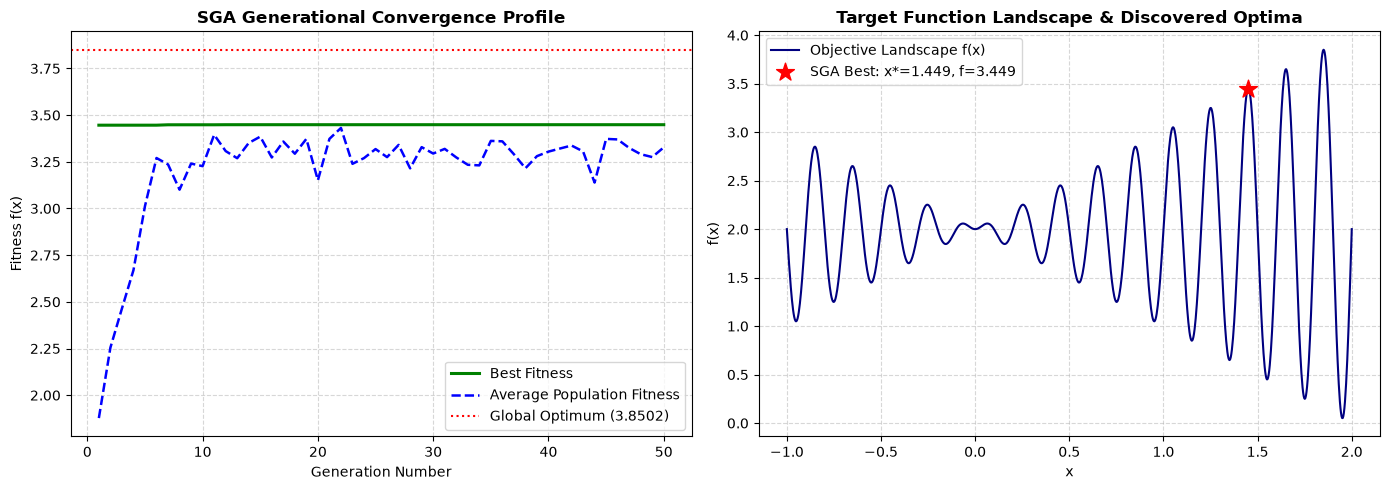


[✓] Plot saved successfully to: /Users/manish/Developer/Assignments/Assignment_2_Practicals/Module_3_Genetic_Algorithms/../output_plots/mod3_ex06_simple_genetic_algorithm.png
[✓] Practical 3.6 completed successfully.



In [7]:
import os
import numpy as np
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt

OUTPUT_DIR = os.path.join(os.getcwd(), "..", "output_plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Multimodal Target Function to Maximize: f(x) = x * sin(10*pi*x) + 2.0 on [-1.0, 2.0]
def objective_function(x):
    return x * np.sin(10 * np.pi * x) + 2.0

def decode_chromosome(bitstring, a=-1.0, b=2.0):
    """Decodes binary string of length L into continuous value x in [a, b]."""
    decimal = int("".join(map(str, bitstring)), 2)
    max_decimal = (2 ** len(bitstring)) - 1
    return a + decimal * (b - a) / max_decimal

class SimpleGeneticAlgorithm:
    def __init__(self, pop_size=50, chrom_len=20, n_gen=60, pc=0.8, pm=0.03):
        self.pop_size = pop_size
        self.chrom_len = chrom_len
        self.n_gen = n_gen
        self.pc = pc
        self.pm = pm
        self.best_history = []
        self.avg_history = []
        self.best_individual = None
        self.best_fitness = -np.inf

    def evolve(self):
        np.random.seed(42)
        # 1. Initialize Population
        pop = np.random.randint(0, 2, size=(self.pop_size, self.chrom_len))

        for gen in range(self.n_gen):
            # Decode & Evaluate
            decoded_vals = np.array([decode_chromosome(ind) for ind in pop])
            fitnesses = objective_function(decoded_vals)

            # Track Statistics
            gen_best_idx = np.argmax(fitnesses)
            gen_best_fit = fitnesses[gen_best_idx]
            gen_avg_fit = np.mean(fitnesses)

            self.best_history.append(gen_best_fit)
            self.avg_history.append(gen_avg_fit)

            if gen_best_fit > self.best_fitness:
                self.best_fitness = gen_best_fit
                self.best_individual = pop[gen_best_idx].copy()
                self.best_x = decoded_vals[gen_best_idx]

            # 2. Elitism: Keep best individual
            new_pop = [pop[gen_best_idx].copy()]

            # 3. Selection, Crossover, and Mutation loop
            while len(new_pop) < self.pop_size:
                # Tournament Selection (k=3)
                p1_idx = np.random.choice(self.pop_size, size=3)
                p1 = pop[p1_idx[np.argmax(fitnesses[p1_idx])]]

                p2_idx = np.random.choice(self.pop_size, size=3)
                p2 = pop[p2_idx[np.argmax(fitnesses[p2_idx])]]

                # Crossover
                if np.random.rand() < self.pc:
                    k = np.random.randint(1, self.chrom_len)
                    c1 = np.concatenate([p1[:k], p2[k:]])
                    c2 = np.concatenate([p2[:k], p1[k:]])
                else:
                    c1, c2 = p1.copy(), p2.copy()

                # Mutation
                for child in [c1, c2]:
                    flips = np.random.rand(self.chrom_len) < self.pm
                    child[flips] = 1 - child[flips]
                    if len(new_pop) < self.pop_size:
                        new_pop.append(child)

            pop = np.array(new_pop)

        return self.best_x, self.best_fitness

def run_practical_3_6():
    print("=" * 60)
    print("PRACTICAL 3.6: Simple Genetic Algorithm (SGA)")
    print("=" * 60)

    sga = SimpleGeneticAlgorithm(pop_size=60, chrom_len=22, n_gen=50, pc=0.85, pm=0.02)
    best_x, best_fit = sga.evolve()

    print(f"Target Problem: Maximize f(x) = x * sin(10*pi*x) + 2.0 on [-1.0, 2.0]")
    print(f"\nOptimization Results after {sga.n_gen} Generations:")
    print(f"Optimal Parameter x* = {best_x:.6f}")
    print(f"Maximum Fitness f(x*) = {best_fit:.6f}")
    print(f"Theoretical Global Maximum ≈ 3.8502 at x ≈ 1.8506")

    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Optimization Curve
    generations = range(1, sga.n_gen + 1)
    ax1.plot(generations, sga.best_history, 'g-', linewidth=2.2, label='Best Fitness')
    ax1.plot(generations, sga.avg_history, 'b--', linewidth=1.8, label='Average Population Fitness')
    ax1.axhline(3.8502, color='red', linestyle=':', label='Global Optimum (3.8502)')
    ax1.set_title("SGA Generational Convergence Profile", fontweight='bold')
    ax1.set_xlabel("Generation Number")
    ax1.set_ylabel("Fitness f(x)")
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend()

    # Plot 2: Fitness Landscape & Optimal Solution Discovered
    x_plot = np.linspace(-1.0, 2.0, 1000)
    y_plot = objective_function(x_plot)
    ax2.plot(x_plot, y_plot, 'navy', linewidth=1.5, label='Objective Landscape f(x)')
    ax2.scatter(best_x, best_fit, color='red', s=180, marker='*', zorder=5,
                label=f'SGA Best: x*={best_x:.3f}, f={best_fit:.3f}')
    ax2.set_title("Target Function Landscape & Discovered Optima", fontweight='bold')
    ax2.set_xlabel("x")
    ax2.set_ylabel("f(x)")
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend()

    plt.tight_layout()
    plot_path = os.path.join(OUTPUT_DIR, "mod3_ex06_simple_genetic_algorithm.png")
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f"\n[✓] Plot saved successfully to: {plot_path}")
    print("[✓] Practical 3.6 completed successfully.\n")

if True:
    run_practical_3_6()

## Practical 7: Practical 3.7: Convergence Analysis and Diversity Tracking in Genetic Algorithms

```
Practical 3.7: Convergence Analysis and Diversity Tracking in Genetic Algorithms
Course: Soft Computing (EL1) - STDA2102 | Module 3: Genetic Algorithms

Aim:
To study the convergence of a Genetic Algorithm by observing changes in fitness values over multiple generations using Python.

Theory:
Convergence analysis in Evolutionary Computation examines the search dynamics across generational time:
1. Best Fitness Curve: Tracks highest achieved adaptation (monotonically non-decreasing under elitism).
2. Mean Fitness Curve: Measures overall population quality improvement.
3. Worst Fitness: Captures exploratory excursions driven by mutation.
4. Population Diversity: The standard deviation of the population's genes:
       Diversity(t) = (1/N) * ∑ ||x_i(t) - x_mean(t)||
   High diversity early represents broad exploration; diminishing diversity reflects exploitation/convergence.
```

PRACTICAL 3.7: Genetic Algorithm Convergence & Diversity Analysis

Convergence History Sample (Generations 1, 10, 25, 50):
 Generation  |  Best Fitness  |  Mean Fitness  |  Diversity  
------------------------------------------------------------
Gen  1       |        99.4233 |        82.3027 |       3.9563
Gen 10       |       100.0000 |        99.9873 |       0.0527
Gen 25       |       100.0000 |        99.9841 |       0.0484
Gen 50       |       100.0000 |        99.9888 |       0.0273


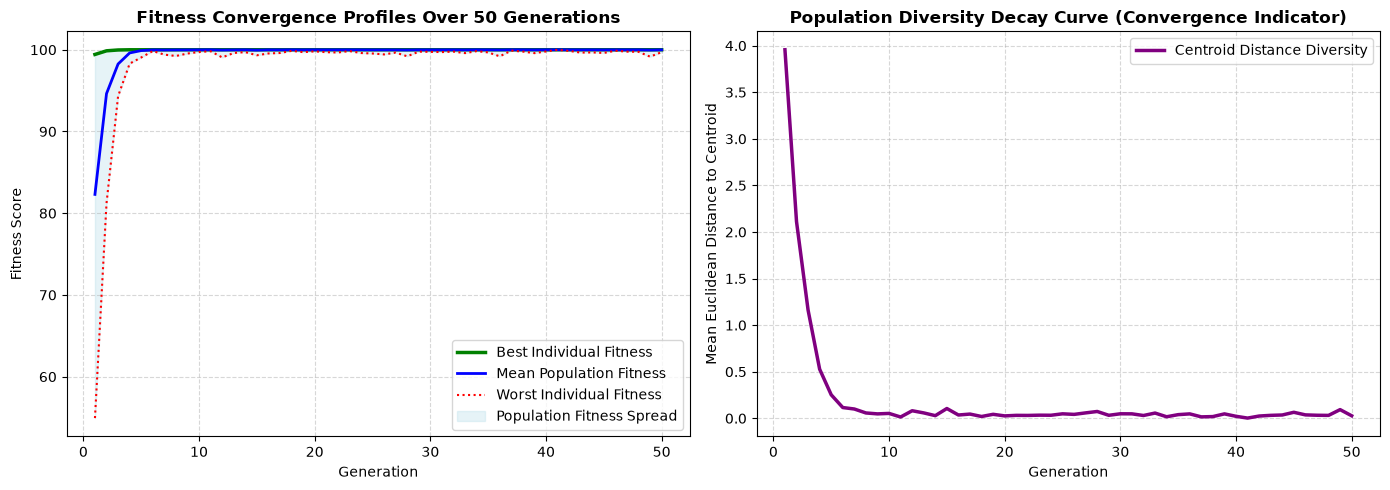


[✓] Plot saved successfully to: /Users/manish/Developer/Assignments/Assignment_2_Practicals/Module_3_Genetic_Algorithms/../output_plots/mod3_ex07_convergence_analysis.png
[✓] Practical 3.7 completed successfully.



In [8]:
import os
import numpy as np
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt

OUTPUT_DIR = os.path.join(os.getcwd(), "..", "output_plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 2D Sphere Function Optimization (Minimization -> Maximization: f(x) = 100 - (x1^2 + x2^2))
def fitness_function(X):
    return 100.0 - np.sum(X ** 2, axis=-1)

def run_ga_tracking(pop_size=60, n_gen=50, pm=0.05, k_tournament=3):
    np.random.seed(42)
    dim = 2
    # Initialize real-valued population in [-5, 5]
    pop = np.random.uniform(-5.0, 5.0, size=(pop_size, dim))

    best_history = []
    mean_history = []
    worst_history = []
    diversity_history = []

    for gen in range(n_gen):
        fits = fitness_function(pop)

        best_history.append(np.max(fits))
        mean_history.append(np.mean(fits))
        worst_history.append(np.min(fits))

        # Diversity: Mean Euclidean distance to population centroid
        centroid = np.mean(pop, axis=0)
        diversity = np.mean(np.linalg.norm(pop - centroid, axis=1))
        diversity_history.append(diversity)

        # Elitism
        best_ind = pop[np.argmax(fits)].copy()
        new_pop = [best_ind]

        # Selection & Variation
        while len(new_pop) < pop_size:
            # Tournament selection
            c1 = np.random.choice(pop_size, size=k_tournament)
            p1 = pop[c1[np.argmax(fits[c1])]]
            c2 = np.random.choice(pop_size, size=k_tournament)
            p2 = pop[c2[np.argmax(fits[c2])]]

            # Arithmetic Crossover
            alpha = np.random.rand()
            child = alpha * p1 + (1.0 - alpha) * p2

            # Gaussian Mutation
            if np.random.rand() < pm:
                child += np.random.normal(0, 0.3, size=dim)
            child = np.clip(child, -5.0, 5.0)
            new_pop.append(child)

        pop = np.array(new_pop)

    return {
        'best': np.array(best_history),
        'mean': np.array(mean_history),
        'worst': np.array(worst_history),
        'diversity': np.array(diversity_history)
    }

def run_practical_3_7():
    print("=" * 60)
    print("PRACTICAL 3.7: Genetic Algorithm Convergence & Diversity Analysis")
    print("=" * 60)

    stats = run_ga_tracking(pop_size=60, n_gen=50, pm=0.08, k_tournament=3)

    print("\nConvergence History Sample (Generations 1, 10, 25, 50):")
    print(f"{'Generation':^12} | {'Best Fitness':^14} | {'Mean Fitness':^14} | {'Diversity':^12}")
    print("-" * 60)
    for g in [0, 9, 24, 49]:
        print(f"Gen {g+1:2d}       | {stats['best'][g]:14.4f} | {stats['mean'][g]:14.4f} | {stats['diversity'][g]:12.4f}")

    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    generations = range(1, 51)

    # Plot 1: Fitness Convergence Envelope
    ax1.plot(generations, stats['best'], 'g-', linewidth=2.5, label='Best Individual Fitness')
    ax1.plot(generations, stats['mean'], 'b-', linewidth=2.0, label='Mean Population Fitness')
    ax1.plot(generations, stats['worst'], 'r:', linewidth=1.5, label='Worst Individual Fitness')
    ax1.fill_between(generations, stats['worst'], stats['best'], color='lightblue', alpha=0.3, label='Population Fitness Spread')
    ax1.set_title("Fitness Convergence Profiles Over 50 Generations", fontweight='bold')
    ax1.set_xlabel("Generation")
    ax1.set_ylabel("Fitness Score")
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(loc='lower right')

    # Plot 2: Population Genetic Diversity Dynamics
    ax2.plot(generations, stats['diversity'], color='purple', linewidth=2.5, label='Centroid Distance Diversity')
    ax2.set_title("Population Diversity Decay Curve (Convergence Indicator)", fontweight='bold')
    ax2.set_xlabel("Generation")
    ax2.set_ylabel("Mean Euclidean Distance to Centroid")
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend()

    plt.tight_layout()
    plot_path = os.path.join(OUTPUT_DIR, "mod3_ex07_convergence_analysis.png")
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f"\n[✓] Plot saved successfully to: {plot_path}")
    print("[✓] Practical 3.7 completed successfully.\n")

if True:
    run_practical_3_7()

## Practical 8: Practical 3.8: Particle Swarm Optimization (PSO) Algorithm

```
Practical 3.8: Particle Swarm Optimization (PSO) Algorithm
Course: Soft Computing (EL1) - STDA2102 | Module 3: Genetic Algorithms

Aim:
To implement a simple Particle Swarm Optimization (PSO) algorithm for solving an optimization problem using Python.

Theory:
Particle Swarm Optimization (James Kennedy and Russell Eberhart, 1995) is a nature-inspired metaheuristic
based on the social foraging behaviors of bird flocks and fish schools.
State equations for particle i at iteration t:
1. Velocity Update:
       v_i(t+1) = w * v_i(t) + c1 * r1 * (pbest_i - x_i(t)) + c2 * r2 * (gbest - x_i(t))
   where:
   - w: Inertia weight (balances exploration vs exploitation).
   - c1: Cognitive coefficient (pull toward individual historical best).
   - c2: Social coefficient (pull toward swarm-wide global best).
   - r1, r2: Uniform random vectors ∈ [0, 1].
2. Position Update:
       x_i(t+1) = x_i(t) + v_i(t+1)
```

PRACTICAL 3.8: Particle Swarm Optimization (PSO)
Objective Function: 2D Rosenbrock Function (Banana Valley)
Theoretical Global Minimum at x* = (1.0, 1.0) with f(x*) = 0.0

PSO Found Minimum Position: (1.00063, 1.00118)
Best Cost Value f(gbest):  0.000001


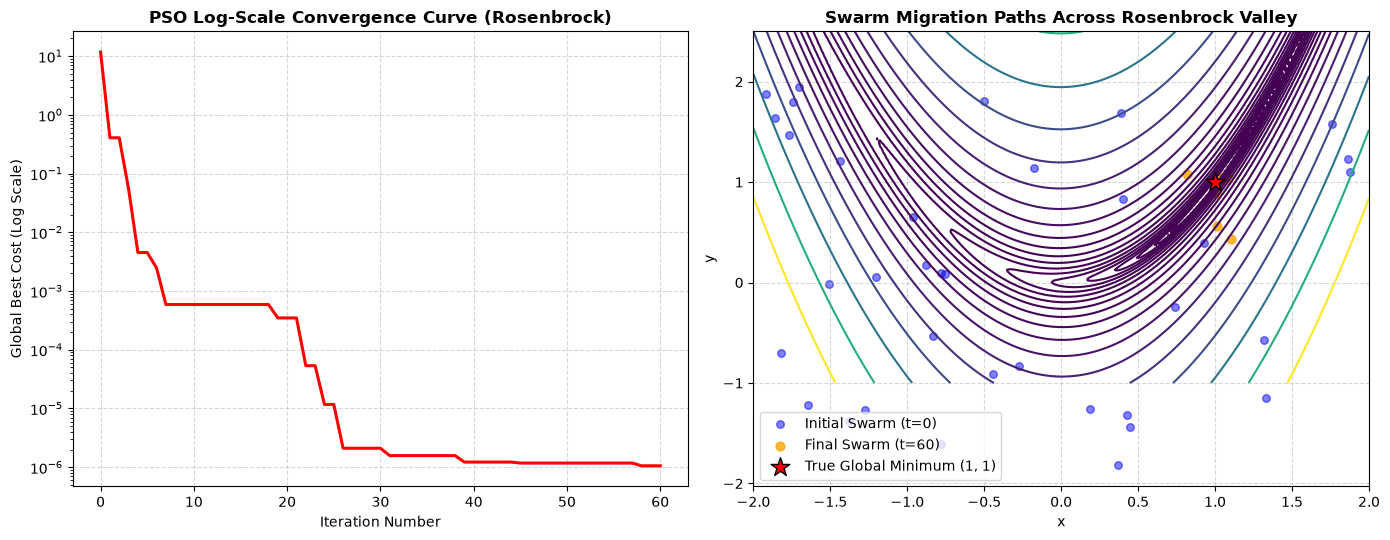


[✓] Plot saved successfully to: /Users/manish/Developer/Assignments/Assignment_2_Practicals/Module_3_Genetic_Algorithms/../output_plots/mod3_ex08_particle_swarm_optimization.png
[✓] Practical 3.8 completed successfully.



In [9]:
import os
import numpy as np
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt

OUTPUT_DIR = os.path.join(os.getcwd(), "..", "output_plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Target: 2D Rosenbrock Function (Banana valley): f(x, y) = (1 - x)^2 + 100*(y - x^2)^2
# Global minimum: f(1, 1) = 0
def rosenbrock(X):
    x, y = X[..., 0], X[..., 1]
    return (1.0 - x)**2 + 100.0 * (y - x**2)**2

class ParticleSwarmOptimizer:
    def __init__(self, n_particles=30, dim=2, bounds=(-2.0, 2.0),
                 w=0.7, c1=1.5, c2=1.5, n_iter=60):
        self.n_particles = n_particles
        self.dim = dim
        self.bounds = bounds
        self.w = w
        self.c1 = c1
        self.c2 = c2
        self.n_iter = n_iter

    def optimize(self):
        np.random.seed(42)
        lb, ub = self.bounds

        # Initialize positions & velocities
        X = np.random.uniform(lb, ub, size=(self.n_particles, self.dim))
        V = np.random.uniform(-0.5, 0.5, size=(self.n_particles, self.dim))

        pbest = X.copy()
        pbest_val = rosenbrock(pbest)

        gbest_idx = np.argmin(pbest_val)
        gbest = pbest[gbest_idx].copy()
        gbest_val = pbest_val[gbest_idx]

        history_gbest = [gbest_val]
        particle_trajectories = [X.copy()]

        for it in range(self.n_iter):
            r1 = np.random.rand(self.n_particles, self.dim)
            r2 = np.random.rand(self.n_particles, self.dim)

            # Update velocity & position
            V = self.w * V + self.c1 * r1 * (pbest - X) + self.c2 * r2 * (gbest - X)
            # Velocity clamping
            V = np.clip(V, -1.0, 1.0)
            X = X + V
            X = np.clip(X, lb, ub)

            particle_trajectories.append(X.copy())

            # Evaluate fitness
            current_vals = rosenbrock(X)

            # Update personal bests
            better_mask = current_vals < pbest_val
            pbest[better_mask] = X[better_mask]
            pbest_val[better_mask] = current_vals[better_mask]

            # Update global best
            if np.min(pbest_val) < gbest_val:
                gbest_val = np.min(pbest_val)
                gbest = pbest[np.argmin(pbest_val)].copy()

            history_gbest.append(gbest_val)

        return gbest, gbest_val, history_gbest, np.array(particle_trajectories)

def run_practical_3_8():
    print("=" * 60)
    print("PRACTICAL 3.8: Particle Swarm Optimization (PSO)")
    print("=" * 60)

    pso = ParticleSwarmOptimizer(n_particles=35, dim=2, bounds=(-2.0, 2.0), n_iter=60)
    gbest, gbest_val, history, trajectories = pso.optimize()

    print(f"Objective Function: 2D Rosenbrock Function (Banana Valley)")
    print(f"Theoretical Global Minimum at x* = (1.0, 1.0) with f(x*) = 0.0")
    print(f"\nPSO Found Minimum Position: ({gbest[0]:.5f}, {gbest[1]:.5f})")
    print(f"Best Cost Value f(gbest):  {gbest_val:.6f}")

    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

    # Plot 1: Optimization Convergence Curve
    ax1.plot(range(len(history)), history, 'r-', linewidth=2.2)
    ax1.set_yscale('log')
    ax1.set_title("PSO Log-Scale Convergence Curve (Rosenbrock)", fontweight='bold')
    ax1.set_xlabel("Iteration Number")
    ax1.set_ylabel("Global Best Cost (Log Scale)")
    ax1.grid(True, linestyle='--', alpha=0.5)

    # Plot 2: Contour Plot with Swarm Trajectories
    x_span = np.linspace(-2.0, 2.0, 200)
    y_span = np.linspace(-1.0, 2.5, 200)
    XX, YY = np.meshgrid(x_span, y_span)
    grid = np.stack([XX, YY], axis=-1)
    ZZ = rosenbrock(grid)

    contour = ax2.contour(XX, YY, ZZ, levels=np.logspace(-1, 3, 20), cmap='viridis')
    ax2.scatter(trajectories[0, :, 0], trajectories[0, :, 1], color='blue', alpha=0.5, s=30, label='Initial Swarm (t=0)')
    ax2.scatter(trajectories[-1, :, 0], trajectories[-1, :, 1], color='orange', alpha=0.8, s=40, label='Final Swarm (t=60)')
    ax2.scatter(1.0, 1.0, color='red', marker='*', s=200, edgecolors='k', zorder=10, label='True Global Minimum (1, 1)')
    ax2.set_title("Swarm Migration Paths Across Rosenbrock Valley", fontweight='bold')
    ax2.set_xlabel("x")
    ax2.set_ylabel("y")
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend(loc='lower left')

    plt.tight_layout()
    plot_path = os.path.join(OUTPUT_DIR, "mod3_ex08_particle_swarm_optimization.png")
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f"\n[✓] Plot saved successfully to: {plot_path}")
    print("[✓] Practical 3.8 completed successfully.\n")

if True:
    run_practical_3_8()

## Practical 9: Practical 3.9: Differential Evolution (DE) Optimization Algorithm

```
Practical 3.9: Differential Evolution (DE) Optimization Algorithm
Course: Soft Computing (EL1) - STDA2102 | Module 3: Genetic Algorithms

Aim:
To implement a simple Differential Evolution (DE) algorithm for solving an optimization problem using Python.

Theory:
Differential Evolution (Rainer Storn and Kenneth Price, 1997) is an exceptionally robust global optimizer
operating on continuous real-valued spaces.
The canonical strategy is DE/rand/1/bin:
1. Mutation: For each target vector x_i, select 3 mutually distinct random agents r1 ≠ r2 ≠ r3 ≠ i:
       v_i = x_r1 + F * (x_r2 - x_r3)
   where F ∈ [0, 2] is the differential weight / scaling factor.
2. Binomial Crossover: Yields trial vector u_i:
       u_{i, j} = v_{i, j}  if (rand(0,1) <= CR  or  j == j_rand)  else  x_{i, j}
   where CR ∈ [0, 1] is the crossover probability, and j_rand ensures at least one mutated allele is transferred.
3. One-to-One Greedy Selection:
       x_i(t+1) = u_i  if f(u_i) <= f(x_i)  else  x_i
```

PRACTICAL 3.9: Differential Evolution (DE/rand/1/bin)
Target Problem: 2D Ackley Optimization (Highly Multimodal Surface)
Global Optimum: x* = (0, 0) with f(x*) = 0.0

DE Discovered Solution: x* = (-0.000000, 0.000000)
Optimal Fitness: f(x*)   = 0.00000028


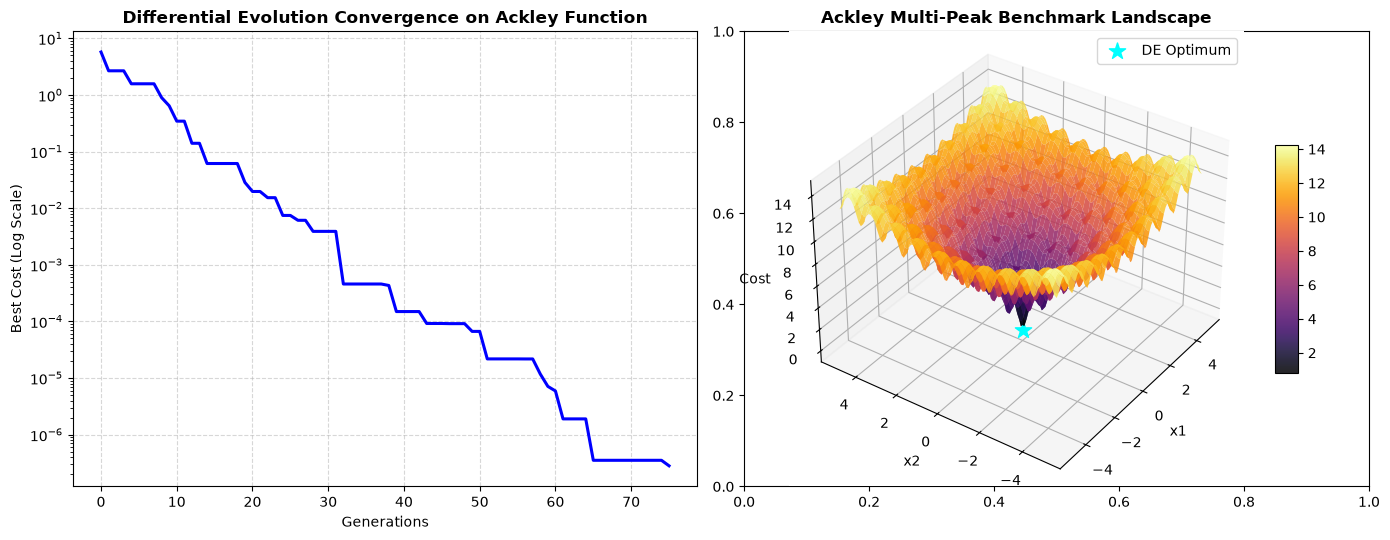


[✓] Plot saved successfully to: /Users/manish/Developer/Assignments/Assignment_2_Practicals/Module_3_Genetic_Algorithms/../output_plots/mod3_ex09_differential_evolution.png
[✓] Practical 3.9 completed successfully.



In [10]:
import os
import numpy as np
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt

OUTPUT_DIR = os.path.join(os.getcwd(), "..", "output_plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Complex Multimodal Benchmark: Ackley Function
# Global minimum: f(0, 0, ...) = 0
def ackley(X):
    d = X.shape[-1]
    sum_sq = np.sum(X**2, axis=-1)
    sum_cos = np.sum(np.cos(2 * np.pi * X), axis=-1)
    term1 = -20.0 * np.exp(-0.2 * np.sqrt(sum_sq / d))
    term2 = -np.exp(sum_cos / d)
    return term1 + term2 + 20.0 + np.e

class DifferentialEvolution:
    def __init__(self, pop_size=40, dim=2, bounds=(-5.0, 5.0),
                 F=0.8, CR=0.9, max_gen=80):
        self.pop_size = pop_size
        self.dim = dim
        self.bounds = bounds
        self.F = F
        self.CR = CR
        self.max_gen = max_gen

    def optimize(self):
        np.random.seed(42)
        lb, ub = self.bounds

        # Initialize population
        pop = np.random.uniform(lb, ub, size=(self.pop_size, self.dim))
        fitness = ackley(pop)

        best_idx = np.argmin(fitness)
        best_agent = pop[best_idx].copy()
        best_cost = fitness[best_idx]
        history = [best_cost]

        for gen in range(self.max_gen):
            for i in range(self.pop_size):
                # Select 3 candidates different from i
                candidates = [idx for idx in range(self.pop_size) if idx != i]
                r1, r2, r3 = np.random.choice(candidates, size=3, replace=False)

                # Mutation
                mutant = pop[r1] + self.F * (pop[r2] - pop[r3])
                mutant = np.clip(mutant, lb, ub)

                # Binomial Crossover
                cross_points = np.random.rand(self.dim) < self.CR
                if not np.any(cross_points):
                    cross_points[np.random.randint(0, self.dim)] = True

                trial = np.where(cross_points, mutant, pop[i])

                # Selection
                trial_fit = ackley(trial)
                if trial_fit <= fitness[i]:
                    pop[i] = trial
                    fitness[i] = trial_fit

                    if trial_fit < best_cost:
                        best_cost = trial_fit
                        best_agent = trial.copy()

            history.append(best_cost)

        return best_agent, best_cost, history

def run_practical_3_9():
    print("=" * 60)
    print("PRACTICAL 3.9: Differential Evolution (DE/rand/1/bin)")
    print("=" * 60)

    de = DifferentialEvolution(pop_size=40, dim=2, bounds=(-5.0, 5.0), F=0.8, CR=0.85, max_gen=75)
    best_x, best_fit, history = de.optimize()

    print(f"Target Problem: 2D Ackley Optimization (Highly Multimodal Surface)")
    print(f"Global Optimum: x* = (0, 0) with f(x*) = 0.0")
    print(f"\nDE Discovered Solution: x* = ({best_x[0]:.6f}, {best_x[1]:.6f})")
    print(f"Optimal Fitness: f(x*)   = {best_fit:.8f}")

    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

    # Convergence Plot
    ax1.plot(range(len(history)), history, 'b-', linewidth=2.2)
    ax1.set_yscale('log')
    ax1.set_title("Differential Evolution Convergence on Ackley Function", fontweight='bold')
    ax1.set_xlabel("Generations")
    ax1.set_ylabel("Best Cost (Log Scale)")
    ax1.grid(True, linestyle='--', alpha=0.5)

    # 3D Ackley Landscape
    x_span = np.linspace(-5.0, 5.0, 100)
    y_span = np.linspace(-5.0, 5.0, 100)
    XX, YY = np.meshgrid(x_span, y_span)
    grid = np.stack([XX, YY], axis=-1)
    ZZ = ackley(grid)

    ax2 = fig.add_subplot(122, projection='3d')
    surf = ax2.plot_surface(XX, YY, ZZ, cmap='inferno', edgecolor='none', alpha=0.85)
    ax2.scatter(best_x[0], best_x[1], best_fit, color='cyan', s=150, marker='*', label='DE Optimum')
    ax2.set_title("Ackley Multi-Peak Benchmark Landscape", fontweight='bold')
    ax2.set_xlabel("x1")
    ax2.set_ylabel("x2")
    ax2.set_zlabel("Cost")
    ax2.view_init(elev=35, azim=215)
    fig.colorbar(surf, ax=ax2, shrink=0.5, aspect=10)
    ax2.legend()

    plt.tight_layout()
    plot_path = os.path.join(OUTPUT_DIR, "mod3_ex09_differential_evolution.png")
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f"\n[✓] Plot saved successfully to: {plot_path}")
    print("[✓] Practical 3.9 completed successfully.\n")

if True:
    run_practical_3_9()

## Practical 10: Practical 3.10: Complete Optimization System using DEAP Library

```
Practical 3.10: Complete Optimization System using DEAP Library
Course: Soft Computing (EL1) - STDA2102 | Module 3: Genetic Algorithms

Aim:
To design and implement a complete optimization system using a Genetic Algorithm in Python
with the DEAP library by integrating population initialization, fitness evaluation,
selection, crossover, mutation, and convergence analysis.

Theory:
DEAP (Distributed Evolutionary Algorithms in Python) provides a modular, object-oriented framework:
1. creator: Dynamically constructs Fitness classes (e.g., FitnessMin with negative weights)
   and Individual classes inheriting from standard container types (list/array).
2. Toolbox: A functional registry storing problem-specific genetic operators:
   - Initialization: tools.initRepeat for population instantiation
   - Evaluation: Problem-specific fitness mapping
   - Selection: tools.selTournament (or selRoulette, selNSGA2)
   - Crossover: tools.cxBlend (BLX-α) or tools.cxTwoPoint
   - Mutation: tools.mutGaussian (with specified μ, σ, and per-gene probability indpb)
3. HallOfFame (HoF): Pareto-optimal archive preserving the absolute global elite individuals.
4. Statistics & Logbook: Tracks generational evolution metrics (min, mean, max, std).
```

PRACTICAL 3.10: Complete Optimization System using DEAP
Evolving 100 individuals over 60 generations for 5D Griewank optimization...

--- DEAP Evolutionary Optimization Completed ---
Optimal Vector x* = [3.0783, 4.52567, 0.09999, 0.05595, -0.16543]
Minimum Griewank Cost f(x*) = 0.01597984
Target Global Optimum at Origin = 0.00000000


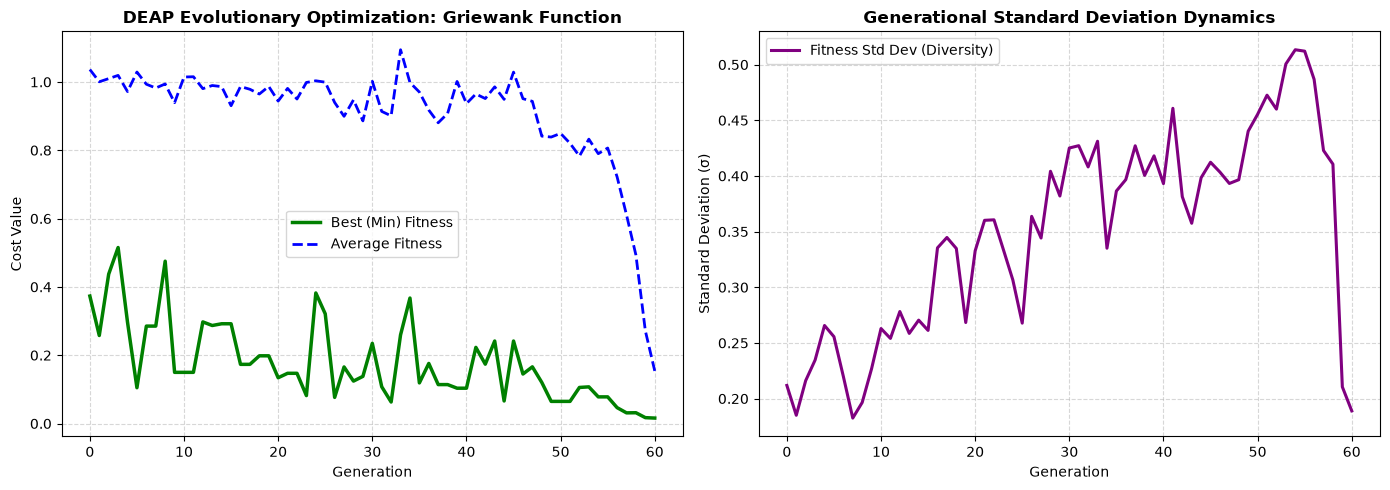


[✓] Plot saved successfully to: /Users/manish/Developer/Assignments/Assignment_2_Practicals/Module_3_Genetic_Algorithms/../output_plots/mod3_ex10_deap_optimization.png
[✓] Practical 3.10 completed successfully.



In [11]:
import os
import random
import numpy as np
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt

from deap import base, creator, tools, algorithms

OUTPUT_DIR = os.path.join(os.getcwd(), "..", "output_plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Problem Definition: 5-Dimensional Griewank Benchmark Function (Minimization)
# Global minimum: f(0, 0, ..., 0) = 0
def griewank_eval(individual):
    x = np.array(individual)
    d = len(x)
    sum_part = np.sum(x**2) / 4000.0
    prod_part = np.prod(np.cos(x / np.sqrt(np.arange(1, d + 1))))
    return (sum_part - prod_part + 1.0,)

def setup_deap_system(dimensions=5, bounds=(-10.0, 10.0)):
    # 1. Setup Fitness and Individual Types
    if not hasattr(creator, "FitnessMin"):
        creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
    if not hasattr(creator, "Individual"):
        creator.create("Individual", list, fitness=creator.FitnessMin)

    toolbox = base.Toolbox()

    # 2. Attribute and Population Registration
    toolbox.register("attr_float", random.uniform, bounds[0], bounds[1])
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_float, n=dimensions)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    # 3. Evolutionary Operators Registration
    toolbox.register("evaluate", griewank_eval)
    toolbox.register("mate", tools.cxBlend, alpha=0.5)
    toolbox.register("mutate", tools.mutGaussian, mu=0.0, sigma=1.0, indpb=0.2)
    toolbox.register("select", tools.selTournament, tournsize=3)

    return toolbox

def run_practical_3_10():
    print("=" * 60)
    print("PRACTICAL 3.10: Complete Optimization System using DEAP")
    print("=" * 60)

    random.seed(42)
    np.random.seed(42)

    dim = 5
    toolbox = setup_deap_system(dimensions=dim, bounds=(-10.0, 10.0))

    # Population & Evolutionary Parameters
    pop_size = 100
    n_gen = 60
    cx_prob = 0.85
    mut_prob = 0.25

    population = toolbox.population(n=pop_size)

    # Hall of Fame (Elite individual archive)
    hof = tools.HallOfFame(1)

    # Statistics & Logbook
    stats = tools.Statistics(lambda ind: ind.fitness.values[0])
    stats.register("min", np.min)
    stats.register("avg", np.mean)
    stats.register("std", np.std)

    # Execute Canonical Evolutionary Algorithm (eaSimple)
    print(f"Evolving {pop_size} individuals over {n_gen} generations for 5D Griewank optimization...")
    pop, logbook = algorithms.eaSimple(
        population, toolbox,
        cxpb=cx_prob, mutpb=mut_prob,
        ngen=n_gen, stats=stats, halloffame=hof,
        verbose=False
    )

    best_ind = hof[0]
    best_cost = best_ind.fitness.values[0]

    print("\n--- DEAP Evolutionary Optimization Completed ---")
    print(f"Optimal Vector x* = {[round(val, 5) for val in best_ind]}")
    print(f"Minimum Griewank Cost f(x*) = {best_cost:.8f}")
    print(f"Target Global Optimum at Origin = 0.00000000")

    # Extract logbook stats
    gen = logbook.select("gen")
    min_fit = logbook.select("min")
    avg_fit = logbook.select("avg")
    std_fit = logbook.select("std")

    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Min and Mean Fitness Curves
    ax1.plot(gen, min_fit, 'g-', linewidth=2.5, label='Best (Min) Fitness')
    ax1.plot(gen, avg_fit, 'b--', linewidth=2.0, label='Average Fitness')
    ax1.set_title("DEAP Evolutionary Optimization: Griewank Function", fontweight='bold')
    ax1.set_xlabel("Generation")
    ax1.set_ylabel("Cost Value")
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend()

    # Plot 2: Fitness Standard Deviation (Diversity Metric)
    ax2.plot(gen, std_fit, 'purple', linewidth=2.2, label='Fitness Std Dev (Diversity)')
    ax2.set_title("Generational Standard Deviation Dynamics", fontweight='bold')
    ax2.set_xlabel("Generation")
    ax2.set_ylabel("Standard Deviation (σ)")
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend()

    plt.tight_layout()
    plot_path = os.path.join(OUTPUT_DIR, "mod3_ex10_deap_optimization.png")
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f"\n[✓] Plot saved successfully to: {plot_path}")
    print("[✓] Practical 3.10 completed successfully.\n")

if True:
    run_practical_3_10()